<a href="https://colab.research.google.com/github/carolcalandrine/Analise-churn/blob/main/projeto_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Churn

Churn refere-se ao momento em que um cliente deixa de utilizar os serviços ou produtos de uma empresa. Esse é um dos principais desafios enfrentados por organizações, especialmente em setores como telecomunicações, bancos e serviços por assinatura, pois a perda de clientes impacta diretamente na receita e no crescimento do negócio.

Dessa forma, compreender os fatores que levam um cliente a cancelar um serviço é essencial para a criação de estratégias de retenção mais eficientes.

## Objetivo do estudo
Realizar uma análise exploratória dos dados para investigar a hipótese de aumento na taxa de churn (cancelamento de clientes) em uma plataforma de serviços por assinatura.

##  Importação de Bibliotecas

In [35]:
#importação de bibliotecas
import pandas as pd #manipular tabelas
import numpy as np #operações
import seaborn as sb #manipular gráficos
import matplotlib.pyplot as plt #manipular gráficos

In [41]:
# Importação do arquivo .csv
df = pd.read_csv('/content/customer_churn_with_months.csv')

# Limpar os nomes das colunas
df.columns = df.columns.str.strip()  #Remove espaços desnecessários

print(df.columns.tolist())

['ID', 'Tipo de empresa', 'Fundação da empresa', 'Possui mais de um sócio', 'Funcionários', 'Meses de permanência', 'Utiliza serviços financeiros', 'PossuiContador', 'Faz conciliação bancária', 'Frequência de utilização de feature do sistema: Módulo financeiro', 'Frequência de utilização de feature do sistema: Emissão de nota fiscal', 'Frequência de utilização de feature do sistema: Integração bancária', 'Frequência de utilização de feature do sistema: Módulo de vendas', 'Frequência de utilização de feature do sistema: Relatórios', 'Frequência de utilização de feature do sistema: Utilização de APIs de integração', 'Contrato', 'Emite boletos', 'Emite boletos.1', 'Tipo de pagamento', 'Receita mensal', 'Receita total', 'Churn', 'mes_churn']


## Dicionário das variáveis

- `customerID`: Identificador único dos clientes
- `Tipo de empresa`: Se a empresa é Micro empresa ou Pequena empresa
- `Fundação da empresa`: Anos de fundação
- `Possui mais de sócio`: Corresponde a sim ou não
- `Funcionários`: Se possui até 5 ou 6 ou mais funcionários
- `Meses de permanência`: 	A quantidade de meses que o cliente está contratado
- `Utiliza serviços financeiros`: Corresponde a Sim ou Não
- `PossuiContador`: Corresponde a Sim ou Não
- `Faz conciliação bancária`: Se a conciliação é automática, manual ou não faz
- `Módulo financeiro`: Uso frequente, pouco uso e nunca utilizou
- `Relatórios`: Uso frequente, pouco uso e nunca utilizou
- `Utilização de APIs de integração`: Se a conciliação é automática, manual ou não faz
- `Contrato`: Mês-a-mês, trimestral e anual
- `Emite boletos`: Se a transação é feita por boletos: 1 ou 0
- `Emite boletos.1`: Se a transação é feita por boletos: Yes ou No
- `Tipo de pagamento`: Cartão de crédito e Boleto
- `Receita mensal`:	A transação por mês realizada por esse cliente
- `Receita total`: A receita total realizada por esse cliente
- `Churn`: Se a houve o churn desse cliente: Sim ou Não
- `mes_churn`: O mês que ocorreu o churn   

## Análise Exploratória dos Dados

### Exploração Univariada

In [ ]:
# Volume dos dados no DataFrame
print(f'Entradas no DataFrame: {df.shape[0]} linhas')
print(f'Variáveis no DataFrame: {df.shape[1]} colunas')

# Primeira e últimas entrada
display(df.head()) #Ver as 5 primeiras linhas
display(df.tail()) # Ver as 5 últimas linhas

Entradas no DataFrame: 7043 linhas
Variáveis no DataFrame: 23 colunas


,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
0,1,Micro empresa,2016,Sim,até 5 funcionários,1,Não,NaN,automática,Pouco uso,...,Pouco uso,Pouco uso,Mês-a-mês,1,Yes,Boleto - pagamento único,29.85,29.85,Não,NaN
1,2,Pequena empresa,2018,Não,até 5 funcionários,34,Sim,Não,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Boleto - mês a mês,56.95,1889.50,Não,NaN
2,4,Pequena empresa,2016,Não,até 5 funcionários,45,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Cartão de crédito - pagamento único,42.30,1840.75,Não,NaN
3,7,Pequena empresa,2019,Não,6 ou mais funcionários,22,Sim,Sim,manual,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Cartão de crédito - mês a mês,89.10,1949.40,Não,NaN
4,8,Micro empresa,2019,Não,até 5 funcionários,10,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Mês-a-mês,0,No,Boleto - mês a mês,29.75,301.90,Não,NaN


,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
7038,4308,Micro empresa,2014,Não,até 5 funcionários,37,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,96.55,3580.30,Sim,05/2025
7039,4950,Pequena empresa,2020,Não,até 5 funcionários,5,Não,NaN,automática,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - mês a mês,51.00,305.95,Sim,05/2025
7040,3303,Pequena empresa,2016,Não,até 5 funcionários,31,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Trimestral,1,Yes,Boleto - pagamento único,103.45,3066.45,Sim,05/2025
7041,5548,Micro empresa,2016,Não,até 5 funcionários,3,Sim,Não,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,89.45,240.45,Sim,05/2025
7042,4291,Micro empresa,2021,Sim,6 ou mais funcionários,1,Não,NaN,automática,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,0,No,Boleto - pagamento único,40.10,40.10,Sim,05/2025


In [19]:
# Overview da tabela
overview = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': round(df.isnull().mean() * 100,2),
    'Valores únicos': df.nunique(),
    'Exemplo de valores': df.apply(lambda x: x.unique()[:3])
})
overview

,Tipo,Nulos,% Nulos,Valores únicos,Exemplo de valores
ID,int64,0,0.00,7043,"[1, 2, 4]"
Tipo de empresa,object,0,0.00,2,"[Micro empresa, Pequena empresa]"
Fundação da empresa,int64,0,0.00,21,"[2016, 2018, 2019]"
Possui mais de um sócio,object,0,0.00,2,"[Sim, Não]"
Funcionários,object,0,0.00,2,"[até 5 funcionários, 6 ou mais funcionários]"
Meses de permanência,int64,0,0.00,73,"[1, 34, 45]"
Utiliza serviços financeiros,object,0,0.00,2,"[Não, Sim]"
PossuiContador,object,682,9.68,2,"[nan, Não , Sim]"
Faz conciliação bancária,object,0,0.00,3,"[automática, manual, não faz]"
Frequência de utilização de feature do sistema: Módulo financeiro,object,0,0.00,3,"[Pouco uso, Uso frequente, Nunca utilizou]"


#### Tipo de Empresa

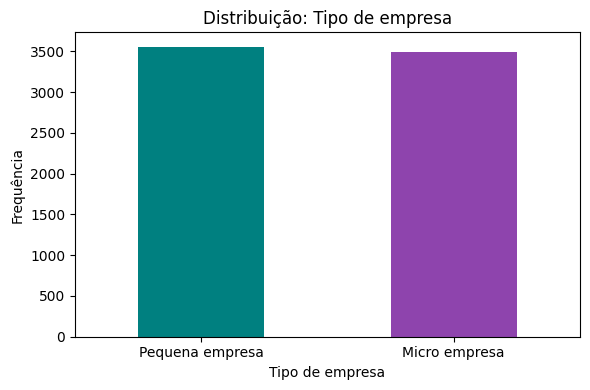

Valores únicos: ['Micro empresa' 'Pequena empresa']
Frequência absoluta: Tipo de empresa
Pequena empresa    3555
Micro empresa      3488
Frequência relativa: Tipo de empresa
Pequena empresa    50.48
Micro empresa      49.52


In [5]:
# Análise da coluna 'Tipo de empresa'

col = 'Tipo de empresa' #col é o nome da coluna (variável)

# Valores únicos
valores_unicos = df[col].unique()

# Frequência Absoluta e Relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True)* 100,2)

# Visualização
plt.figure(figsize=(6,4)) #Define o tamanho da imagem
freq_abs.plot(kind='bar', color=['#008080','#8e44ad']) #kind=bar é o tipo de gráfico, color= cor do gráfico
plt.title('Distribuição: Tipo de empresa') #titulo
plt.xlabel('Tipo de empresa') #nome dos eixos
plt.ylabel('Frequência')
plt.xticks(rotation=0) # rotação
plt.tight_layout() #Ajusta o layout
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

A variável 'Tipo de empresa' é do tipo categórica, e não apresenta valores ausentes ou inconsistentes.
A distribuição mostra que não há uma predominância de um grupo, mas que há um equilíbrio entre as duas variáveis com 50,47% para Pequena empresa e 49,52% para Micro empresa.
Isso pode indicar que existe uma amostragem balanceada e do ponto de vista analítico, essa variável pode ser explorada em análises relacionadas ao churn.

#### Fundação da Empresa

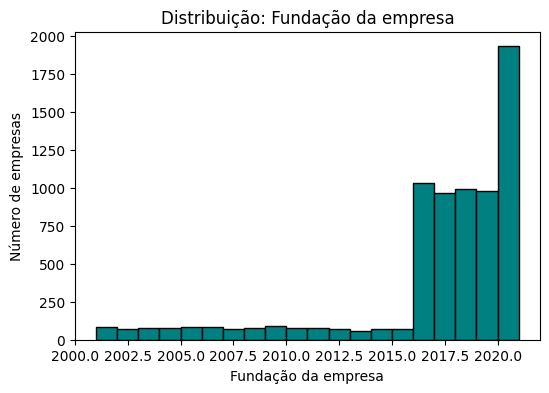

Valores únicos: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Estatística descritiva:
count    7043.00
mean     2016.74
std         4.58
min      2001.00
25%      2016.00
50%      2018.00
75%      2020.00
max      2021.00
Top 5 anos de fundação: Fundação da empresa
2016    1029
2018     990
2019     982
2021     975
2017     969


In [72]:
## Análise da coluna 'Fundação da empresa'
col = 'Fundação da empresa'  #Extraindo a coluna do DataFrame

#Valores unicos
valores_unicos = df[col].unique() #unique: valores únicos, tolist: transforma em lista, sorted: ordem crescente

# Estatística descritiva
stats = round(df[col].describe(),2)

#Frequência dos anos mais comuns
top_anos = df[col].value_counts().head()

#Histograma
plt.figure(figsize=(6,4))
plt.hist(df[col], bins=20, edgecolor='black', color='#008080')
plt.title('Distribuição: Fundação da empresa')
plt.xlabel('Fundação da empresa')
plt.ylabel('Número de empresas')
plt.show()

print(f'Valores únicos: {sorted(valores_unicos.tolist())}')
print(f'Estatística descritiva:\n{stats.to_string()}')
print(f'Top 5 anos de fundação: {top_anos.to_string()}')


#### Possui mais de um sócio

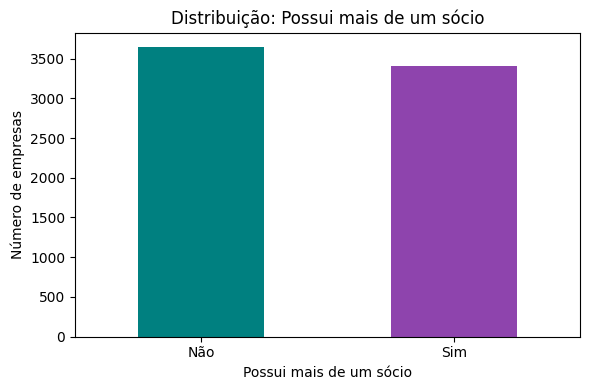

Valores únicos: ['Sim' 'Não']
Frequência absoluta: Possui mais de um sócio
Não    3641
Sim    3402
Frequência relativa: Possui mais de um sócio
Não    51.7
Sim    48.3


In [7]:
# Análise da coluna 'Possui mais de um sócio'

col = 'Possui mais de um sócio'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência Relativa e Absoluta
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Visualização
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Possui mais de um sócio')
plt.xlabel('Possui mais de um sócio')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Funcionários

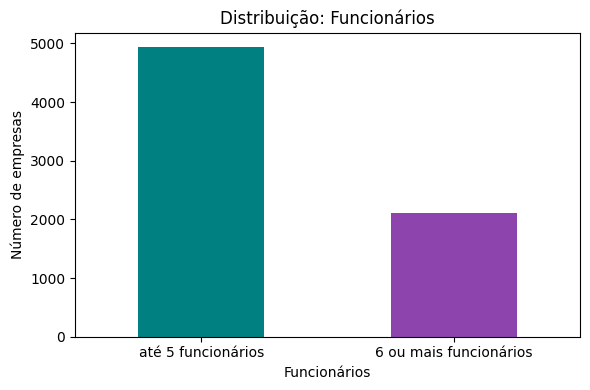

Valores únicos: ['até 5 funcionários' '6 ou mais funcionários']
Frequência absoluta: Funcionários
até 5 funcionários        4933
6 ou mais funcionários    2110
Frequência relativa: Funcionários
até 5 funcionários        70.04
6 ou mais funcionários    29.96


In [8]:
# Análise da variável 'Funcionários'
col = 'Funcionários'

#Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Visualização
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Funcionários')
plt.xlabel('Funcionários')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Meses de Permanência

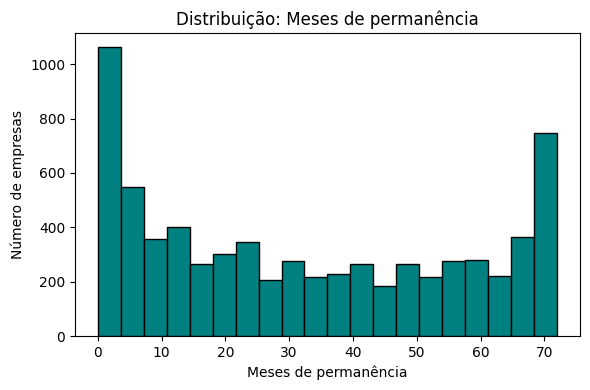

Estatística descritiva:
count    7043.00
mean       32.37
std        24.56
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00


In [53]:
# Análise da coluna 'Meses de permanência'
col = 'Meses de permanência'

# Estatística descritiva
stats = round(df[col].describe(),2)

# Histograma
plt.figure(figsize=(6,4))
plt.hist(df[col], bins=20, edgecolor='black', color= '#008080')
plt.title('Distribuição: Meses de permanência')
plt.xlabel('Meses de permanência')
plt.ylabel('Número de empresas')
plt.tight_layout()
plt.show()

print(f'Estatística descritiva:\n{stats.to_string()}')


#### Utiliza Serviços Financeiros

Valores únicos: ['Não' 'Sim']


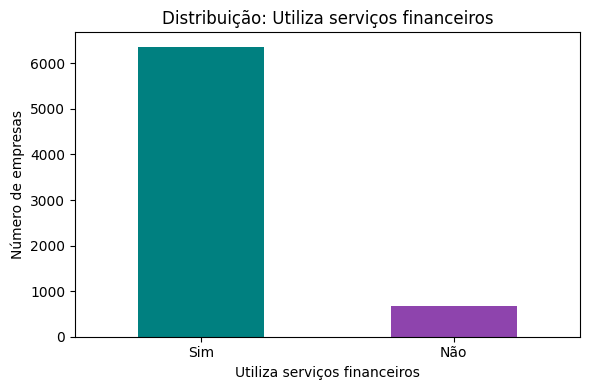

Valores únicos: ['Não' 'Sim']
Frequência absoluta: Utiliza serviços financeiros
Sim    6361
Não     682
Frequência relativa: Utiliza serviços financeiros
Sim    90.32
Não     9.68


In [9]:
# Análise da coluna 'Utiliza serviços financeiros'
col = 'Utiliza serviços financeiros'

# Valores únicos
valores_unicos = df[col].unique()
print(f'Valores únicos: {df[col].unique()}')

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Utiliza serviços financeiros')
plt.xlabel('Utiliza serviços financeiros')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')


Essa variável é uma variável categórica ordinal. Sendo assim pode-se dizer que a maioria dos clientes utilizam serviços financeiros. Então qual seria a relação do churn com essa variável? Quem possui ou não serviços financeiros tende a cancelar a assinatura ?

####Possui Contador

Valores únicos: [nan 'Não ' 'Sim']


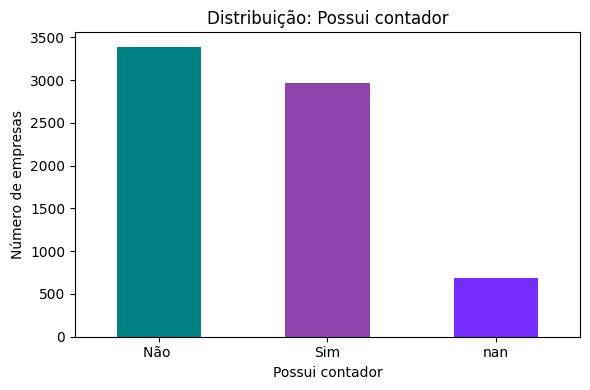

Valores únicos: [nan 'Não ' 'Sim']
Frequência absoluta: PossuiContador
Não     3390
Sim     2971
NaN      682
Frequência relativa: PossuiContador
Não     48.13
Sim     42.18
NaN      9.68


In [11]:
#Análise da coluna 'PossuiContador'
col = 'PossuiContador'

#Valores unicos
valores_unicos = df[col].unique()
print(f'Valores únicos: {valores_unicos}')

#Nulos
nulos = df[col].isnull().sum()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts(dropna=False) # dropna=False para considerar os valores vazios
freq_rel = round(df[col].value_counts(normalize=True, dropna=False) * 100,2)

# Gráfico de barra
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad', '#762CFA'])
plt.title('Distribuição: Possui contador')
plt.xlabel('Possui contador')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Esse 'nan' seriam os valores vazios que não obtiveram resultados em relação a pergunta: se o cliente possui ou não contador sendo 9,68%

#### Faz conciliação bancária

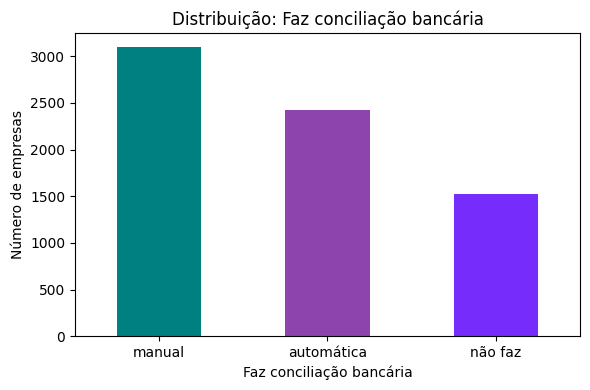

Valores únicos: ['automática' 'manual' 'não faz']
Frequência absoluta: Faz conciliação bancária
manual        3096
automática    2421
não faz       1526
Frequência relativa: Faz conciliação bancária
manual        43.96
automática    34.37
não faz       21.67


In [12]:
# Análise da coluna 'Faz conciliação bancária'

col = 'Faz conciliação bancária'

#Valores únicos
valores_unicos = df[col].unique()

#Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad', '#762CFA'])
plt.title('Distribuição: Faz conciliação bancária')
plt.xlabel('Faz conciliação bancária')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Frequência de utilização de feature do sistema: Módulo financeiro

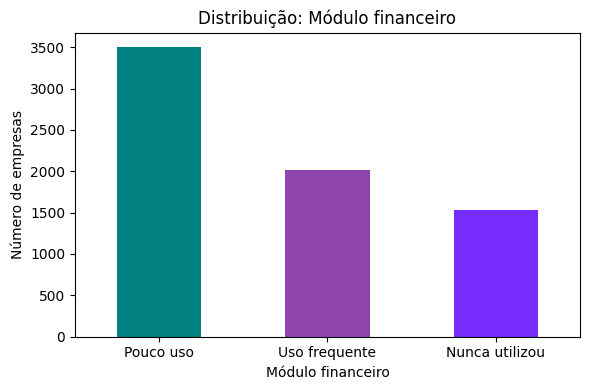

Valores únicos: ['Pouco uso' 'Uso frequente' 'Nunca utilizou']
Frequência absoluta: Frequência de utilização de feature do sistema: Módulo financeiro
Pouco uso         3498
Uso frequente     2019
Nunca utilizou    1526
Frequência relativa: Frequência de utilização de feature do sistema: Módulo financeiro
Pouco uso         49.67
Uso frequente     28.67
Nunca utilizou    21.67


In [13]:
# Análise da coluna 'Módulo financeiro'

col = 'Frequência de utilização de feature do sistema: Módulo financeiro'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad', '#762CFA'])
plt.title('Distribuição: Módulo financeiro')
plt.xlabel('Módulo financeiro')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Emissão de nota fiscal

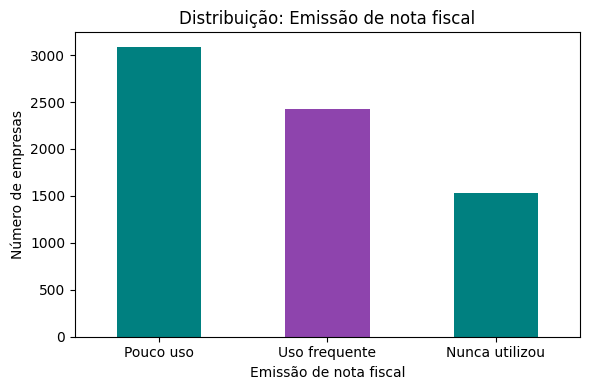

Valores únicos: ['Uso frequente' 'Pouco uso' 'Nunca utilizou']
Frequência absoluta: Frequência de utilização de feature do sistema: Emissão de nota fiscal
Pouco uso         3088
Uso frequente     2429
Nunca utilizou    1526
Frequência relativa: Frequência de utilização de feature do sistema: Emissão de nota fiscal
Pouco uso         43.84
Uso frequente     34.49
Nunca utilizou    21.67


In [14]:
# Análise da coluna 'Emissão de nota fiscal'

col = 'Frequência de utilização de feature do sistema: Emissão de nota fiscal'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color= ['#008080','#8e44ad'])
plt.title('Distribuição: Emissão de nota fiscal')
plt.xlabel('Emissão de nota fiscal')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Contrato

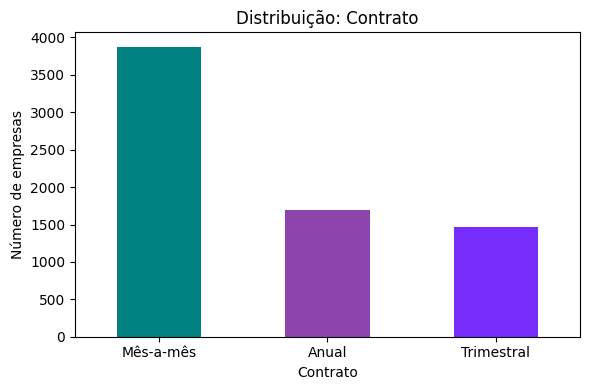

Valores únicos: ['Mês-a-mês' 'Trimestral' 'Anual']
Frequência absoluta: Contrato
Mês-a-mês     3875
Anual         1695
Trimestral    1473
Frequência relativa: Contrato
Mês-a-mês     55.02
Anual         24.07
Trimestral    20.91


In [16]:
# Análise da coluna 'contrato'
col = 'Contrato'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

#Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind= 'bar', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Contrato')
plt.xlabel('Contrato')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Emite boletos

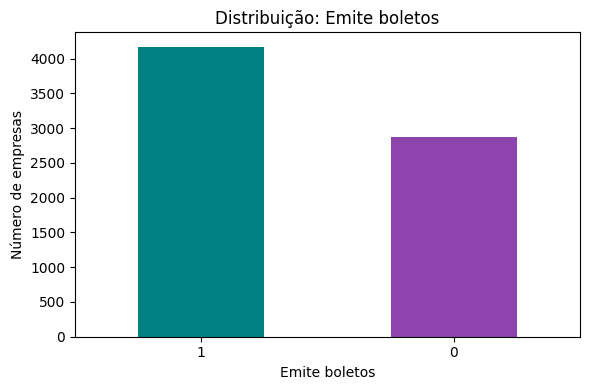

Valores únicos: [1 0]
Frequência absoluta: Emite boletos
1    4171
0    2872
Frequência relativa: Emite boletos
1    59.22
0    40.78


In [17]:
# Análise da coluna 'Emite boletos'
col = 'Emite boletos'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind= 'bar', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Emite boletos')
plt.xlabel('Emite boletos')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Tipo de pagamento

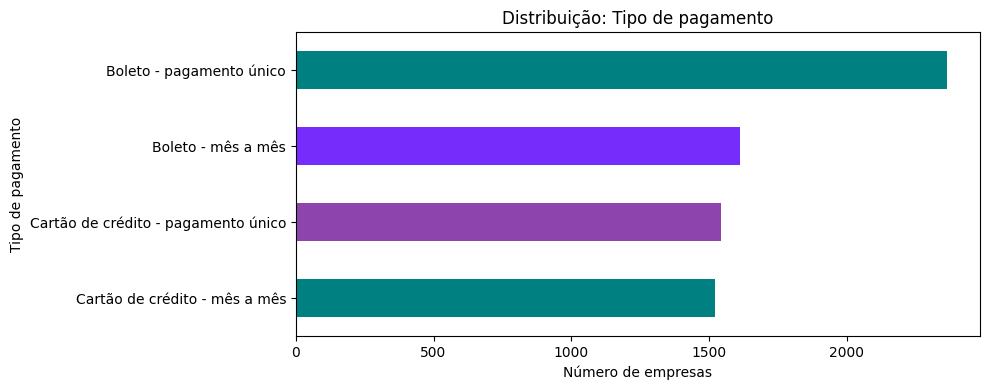

Valores únicos: ['Boleto - pagamento único' 'Boleto - mês a mês'
 'Cartão de crédito - pagamento único' 'Cartão de crédito - mês a mês']
Frequência absoluta: Tipo de pagamento
Boleto - pagamento único               2365
Boleto - mês a mês                     1612
Cartão de crédito - pagamento único    1544
Cartão de crédito - mês a mês          1522
Frequência relativa: Tipo de pagamento
Boleto - pagamento único               33.58
Boleto - mês a mês                     22.89
Cartão de crédito - pagamento único    21.92
Cartão de crédito - mês a mês          21.61


In [ ]:
# Análise da coluna 'Tipo de pagamento'

col = 'Tipo de pagamento'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)


# Gráfico
plt.figure(figsize=(10,4))
freq_abs.sort_values().plot(kind= 'barh', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Tipo de pagamento')
plt.xlabel('Número de empresas')
plt.ylabel('Tipo de pagamento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Receita mensal

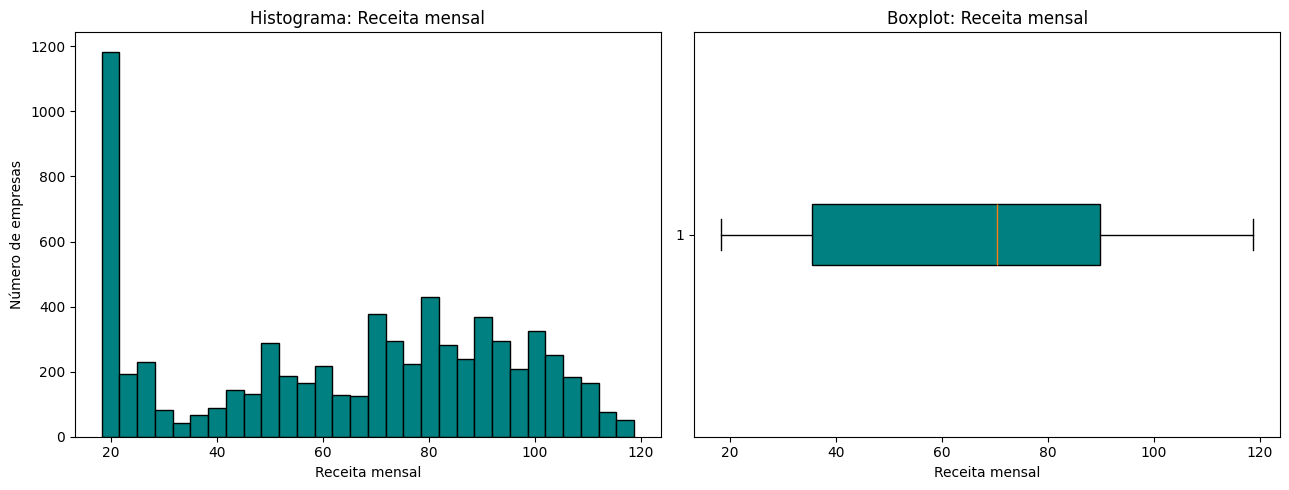

Estatística descritiva:
count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75


In [95]:

# Análise da coluna 'Receita mensal'

col = 'Receita mensal'

# Estatística
est = round(df[col].describe(),2)

# Boxplot e histograma
fig, axs = plt.subplots(1, 2, figsize=(13,5))
axs[0].hist(df[col].dropna(), bins=30, edgecolor='black', color='#008080') # dropna retira os Nan (vazios)
axs[0].set_title('Histograma: Receita mensal')  # O .set_ é sempre usado para axs[0]
axs[0].set_xlabel('Receita mensal')
axs[0].set_ylabel('Número de empresas')
axs[1].boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#008080'))   # patch_artist e boxprops para cores
axs[1].set_title('Boxplot: Receita mensal')
axs[1].set_xlabel('Receita mensal')
plt.tight_layout()
plt.show()

print(f'Estatística descritiva:\n{est.to_string()}')  #\n para pular a linha

#### Receita total

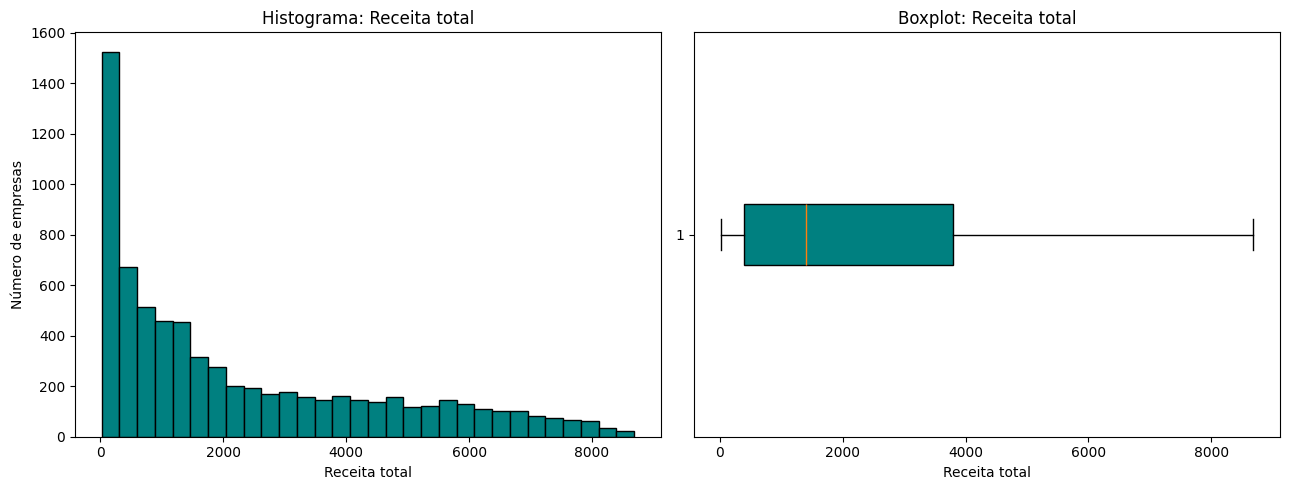

Valores nulos: 11
Estatística descritiva:
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80


In [97]:
# Análise da coluna 'Receita total'

col = 'Receita total'

# Valores nulos
nulos = df[col].isnull().sum()

# Estatística descritiva
est = round(df[col].describe(),2)

# Boxplot e histograma
fig, axs = plt.subplots(1, 2, figsize=(13,5))
axs[0].hist(df[col].dropna(), bins=30, edgecolor= 'black', color='#008080')
axs[0].set_title('Histograma: Receita total')
axs[0].set_xlabel('Receita total')
axs[0].set_ylabel('Número de empresas')
axs[1].boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#008080'))
axs[1].set_title('Boxplot: Receita total')
axs[1].set_xlabel('Receita total')
plt.tight_layout()
plt.show()

print(f'Valores nulos: {nulos}')
print(f'Estatística descritiva:\n{est.to_string()}')

#### Churn

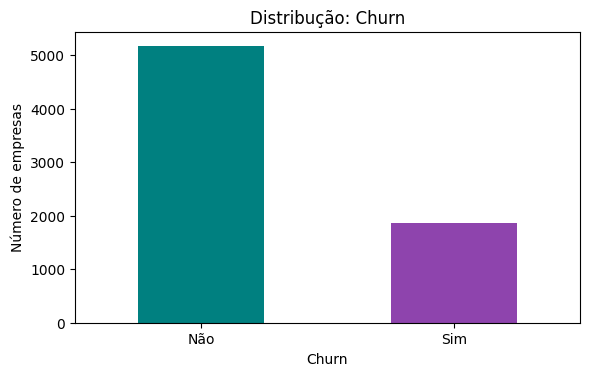

Valores Únicos:['Não' 'Sim']
Frequência absoluta: Churn
Não    5174
Sim    1869
Frequência relativa: Churn
Não    73.46
Sim    26.54


In [ ]:
# Análise coluna 'Churn'

col = 'Churn'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribução: Churn')
plt.xlabel('Churn')
plt.ylabel('Número de empresas')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

print(f'Valores Únicos:{valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

#### Mes churn

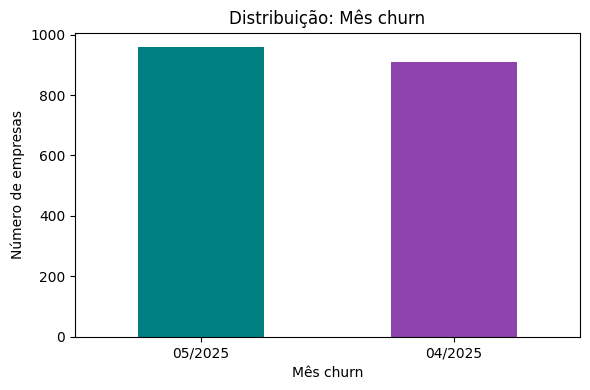

Valores únicos: [nan '04/2025' '05/2025']
Valores nulos: 5174
Frequência absoluta: mes_churn
NaN        5174
05/2025     958
04/2025     911
Frequência relativa: mes_churn
NaN        73.46
05/2025    13.60
04/2025    12.93


In [ ]:
# Análise da coluna 'mes_churn'

col = 'mes_churn'

#Valores únicos
valores_unicos = df[col].unique()

#Valores nulos
nulos = df[col].isnull().sum()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts(dropna=False)
freq_rel = round(df[col].value_counts(dropna=False, normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
df[col].dropna().value_counts().plot(kind= 'bar', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Mês churn')
plt.xlabel('Mês churn')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Valores nulos: {nulos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')